# spatialdetection quickstart

Interactive tour of the library. Every clustering/autocorrelation function
takes a plain `pandas.DataFrame` with `lon`/`lat` columns directly — no
need to build a `GeoDataFrame` yourself first.

Run all cells (Kernel > Restart & Run All), or open this in VS Code with the
Jupyter extension and pick the `spatialdetection` (`.venv`) kernel.

In [1]:
import json
import warnings

import numpy as np
import pandas as pd

from spatialdetection import (
    cluster_summary,
    dbscan_clusters,
    detect_level,
    detect_point,
    district_hotspots,
    getis_ord_hotspots,
    morans_i,
    plot_hotspots,
    plot_level_map,
    province_hotspots,
    spatiotemporal_hotspots,
    subdistrict_hotspots,
)

rng = np.random.default_rng(0)

## 1. Sample data

Synthetic outbreak-style case data: a tight cluster plus scattered
background cases around Bangkok, each with a report date.

In [2]:
cluster = pd.DataFrame(
    {
        "lon": rng.normal(100.50, 0.01, size=30),
        "lat": rng.normal(13.75, 0.01, size=30),
        "cases": rng.poisson(8, size=30),
    }
)
background = pd.DataFrame(
    {
        "lon": rng.uniform(100.3, 100.7, size=40),
        "lat": rng.uniform(13.6, 13.9, size=40),
        "cases": rng.poisson(1, size=40),
    }
)
df = pd.concat([cluster, background], ignore_index=True)
days = pd.to_datetime("2024-06-01") + pd.to_timedelta(rng.integers(0, 5, size=len(df)), unit="D")
df["reported_at"] = days

df.head()

,lon,lat,cases,reported_at
0,100.501257,13.739904,6,2024-06-03
1,100.498679,13.747908,14,2024-06-01
2,100.506404,13.748408,10,2024-06-04
3,100.501049,13.755408,15,2024-06-03
4,100.494643,13.752147,4,2024-06-02


## 2. Density-based cluster detection (DBSCAN)

In [3]:
labels = dbscan_clusters(df, eps_km=1.5, min_samples=5)
summary = cluster_summary(df, labels)
summary[["cluster", "size"]]

,cluster,size
0,0,30


## 3. Spatial autocorrelation / hotspot detection

Global Moran's I tests whether `cases` is spatially clustered at all;
Getis-Ord Gi* flags exactly which points are significant hot/cold spots.

In [4]:
moran = morans_i(df, value_col="cases", k=5, permutations=199)
print(f"Global Moran's I: {moran.I:.3f} (p={moran.p_sim:.3f})")

hotspots = getis_ord_hotspots(df, value_col="cases", k=5, permutations=199)
hotspots["hotspot"].value_counts().rename({1: "hotspot", -1: "coldspot", 0: "not significant"})

Global Moran's I: 0.626 (p=0.005)


hotspot
coldspot           29
not significant    25
hotspot            16
Name: count, dtype: int64

<Axes: >

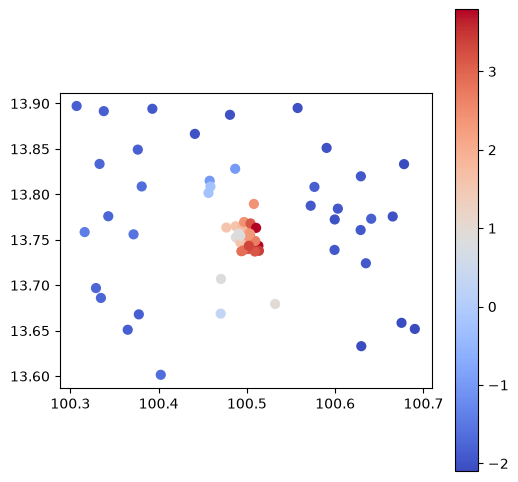

In [5]:
hotspots.plot(column="gi_zscore", cmap="coolwarm", legend=True, markersize=40, figsize=(6, 6))

## 4. Spatiotemporal hotspots

Bin points by day/week/month and run Getis-Ord Gi* independently within
each bin, so a hotspot in one period isn't diluted by activity in another.

In [6]:
by_day = spatiotemporal_hotspots(
    df, time_col="reported_at", value_col="cases", timeframe="day", k=5, permutations=199
)
by_day.groupby("time_bin")["hotspot"].apply(lambda s: (s == 1).sum()).rename("hotspot_points")

time_bin
2024-06-01    7
2024-06-02    7
2024-06-03    8
2024-06-04    9
2024-06-05    0
Name: hotspot_points, dtype: int64

## 5. Detect a Thai admin level and auto-plot it

`detect_level` accepts either a P-code string or a `(lat, lon)` pair and
auto-dispatches; `plot_level_map` renders a map zoomed to whatever level it
finds.

level=province, lat=13.7718, lon=100.6234


<Axes: title={'center': 'Province: Bangkok (TH10)'}>

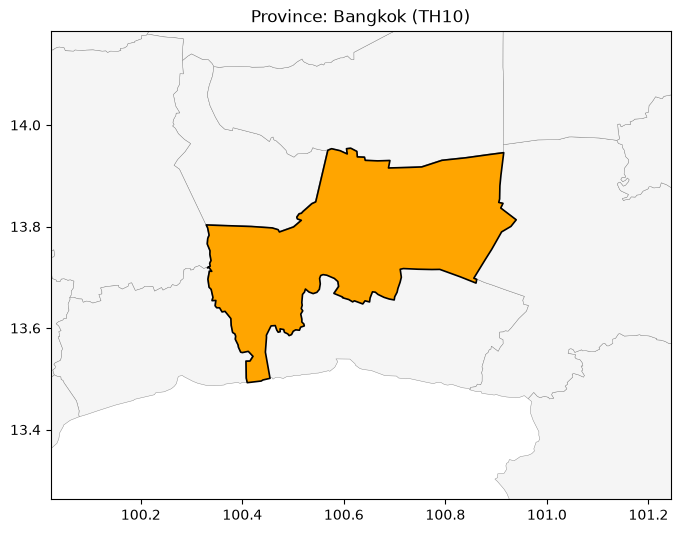

In [7]:
result = detect_level("TH10")  # Bangkok province P-code
print(f"level={result.level}, lat={result.lat:.4f}, lon={result.lon:.4f}")

plot_level_map("TH10")

## 6. Reverse-geocode points to P-codes

`detect_point` is the inverse of `detect_province`/`detect_district`/
`detect_subdistrict`: given a DataFrame of `(lat, lon)` rows, it spatially
resolves which province/district/subdistrict each one falls inside.

In [8]:
located = detect_point(df)
located.groupby("subdistrict_en")["cases"].sum().sort_values(ascending=False).head(10)

subdistrict_en
Phraborom Maharatchawang    34
Bowon Niwet                 29
Wang Burapha Phirom         24
Wat Kanlaya                 22
Talat Noi                   18
Sirirat                     17
Sao Chingcha                16
Bang Khun Phrom             13
Wat Thepsirin               13
Ban Phan Thom               12
Name: cases, dtype: int64

## 7. P-code-tagged multi-disease data: describe, aggregate, and auto-plot anomalies

A larger, more realistic dataset: person-level records already tagged
with a subdistrict P-code (as real line-list data often does), spread
across multiple provinces over a 30-day window, with **two diseases**,
each with its own outbreak province and at least 30,000 cases. Thailand's
P-code scheme is nested -- subdistrict `"TH100101"` = district `"TH1001"`
+ 2 digits = province `"TH10"` + 2 more -- so the parent district/
province codes come from string slicing, no lookup needed. See
`examples/pcode_example.py` for the standalone script this section
mirrors.

In [9]:
def jittered_persons(s, n, start):
    return pd.DataFrame({
        "pcode": s["subdistrict_code"],
        "lat": rng.normal(s["lat"], 0.01, size=n),
        "long": rng.normal(s["lon"], 0.01, size=n),
        "date": start + pd.to_timedelta(rng.integers(0, 30, size=n), unit="D"),
    })

def make_disease_data(outbreak_province_en):
    rows = []
    baseline = subdistricts.groupby("province_code", as_index=False).first()
    for _, s in baseline.iterrows():
        rows.append(jittered_persons(s, rng.integers(20, 80), start))
    chosen = [by_province_en[by_province_en["province_en"] == p].sample(2, random_state=0) for p in background_provinces]
    for _, s in pd.concat(chosen, ignore_index=True).iterrows():
        rows.append(jittered_persons(s, rng.integers(1500, 2500), start))
    outbreak = by_province_en[by_province_en["province_en"] == outbreak_province_en].sample(1, random_state=1)
    for _, s in outbreak.iterrows():
        rows.append(jittered_persons(s, 8_000, start))
    return pd.concat(rows, ignore_index=True)

with open("../data/thailand_admin_centroids.json") as f:
    centroids = json.load(f)
subdistricts = pd.DataFrame(centroids["subdistricts"])
provinces = pd.DataFrame(centroids["provinces"])
by_province_en = subdistricts.merge(provinces[["province_code", "province_en"]], on="province_code")

background_provinces = ["Bangkok", "Chiang Mai", "Khon Kaen", "Nakhon Si Thammarat", "Songkhla", "Nakhon Ratchasima", "Chon Buri"]
# Each disease gets its own outbreak province, not in the background list -> isolated, disease-specific signal
disease_outbreak_province = {"Dengue": "Chiang Rai", "Influenza": "Surat Thani"}
start = pd.to_datetime("2024-05-01")

frames = []
for disease, outbreak_province_en in disease_outbreak_province.items():
    disease_df = make_disease_data(outbreak_province_en)
    disease_df["disease"] = disease
    frames.append(disease_df)
person_df = pd.concat(frames, ignore_index=True)
print(f"{len(person_df)} person records across {person_df['disease'].nunique()} diseases and {person_df['date'].dt.date.nunique()} days")
person_df.head()

81019 person records across 2 diseases and 30 days


,pcode,lat,long,date,disease
0,TH100101,13.739208,100.476578,2024-05-21,Dengue
1,TH100101,13.751241,100.492745,2024-05-30,Dengue
2,TH100101,13.752709,100.480666,2024-05-13,Dengue
3,TH100101,13.760089,100.478586,2024-05-11,Dengue
4,TH100101,13.752627,100.489922,2024-05-29,Dengue


### Data describe: cases per disease

In [10]:
print(person_df.groupby("disease").size().rename("persons"))
person_df.describe(include="all")

disease
Dengue       40930
Influenza    40089
Name: persons, dtype: int64


,pcode,lat,long,date,disease
count,81019,81019.000000,81019.000000,81019,81019
unique,93,NaN,NaN,NaN,2
top,TH570511,NaN,NaN,NaN,Dengue
freq,8000,NaN,NaN,NaN,40930
mean,NaN,13.571235,100.631133,2024-05-15 11:43:29.832261,NaN
min,NaN,6.400412,97.936900,2024-05-01 00:00:00,NaN
25%,NaN,9.420640,99.675055,2024-05-08 00:00:00,NaN
50%,NaN,13.816769,100.481526,2024-05-15 00:00:00,NaN
75%,NaN,16.819611,101.058033,2024-05-23 00:00:00,NaN
max,NaN,19.933204,104.876280,2024-05-30 00:00:00,NaN


### Aggregate by pcode to subdistrict / district / province

No spatial join needed here -- `pcode` is already known per row, so the
parent district/province codes come from string slicing and the rollup
is a plain `groupby`.

In [11]:
person_df["district_code"] = person_df["pcode"].str[:6]
person_df["province_code"] = person_df["pcode"].str[:4]

by_subdistrict = person_df.groupby("pcode").size()
by_district = person_df.groupby("district_code").size()
by_province = person_df.groupby("province_code").size()
print(f"{len(by_subdistrict)} subdistricts, {len(by_district)} districts, {len(by_province)} provinces")

93 subdistricts, 91 districts, 77 provinces


### Detect anomalies at every level and auto-plot each result

`province_hotspots`/`district_hotspots`/`subdistrict_hotspots` take the
same point-level data directly (lat/long), reverse-geocode it with
`detect_point`, and aggregate onto *every* unit at that level.
`plot_hotspots` then auto-plots the result as a choropleth, colored by
`gi_zscore` (continuous, diverging, centered at zero) rather than the
`hotspot` significance flag -- with one dominant outbreak among many
small/baseline counts, that flag can be unreliable even when `gi_zscore`
correctly ranks the outbreak highest (see `level_hotspots.py`).

Text(0.5, 1.0, 'Dengue: province-level gi_zscore')

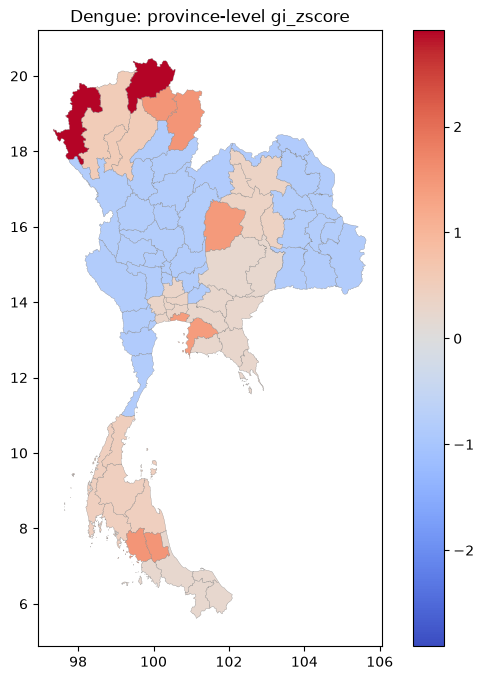

In [12]:
dengue_df = person_df[person_df["disease"] == "Dengue"]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)  # libpysal disconnected-components notice
    dengue_province = province_hotspots(dengue_df, lon_col="long", lat_col="lat", k=5, permutations=499)

plot_hotspots(dengue_province).set_title("Dengue: province-level gi_zscore")

Text(0.5, 1.0, 'Influenza: province-level gi_zscore')

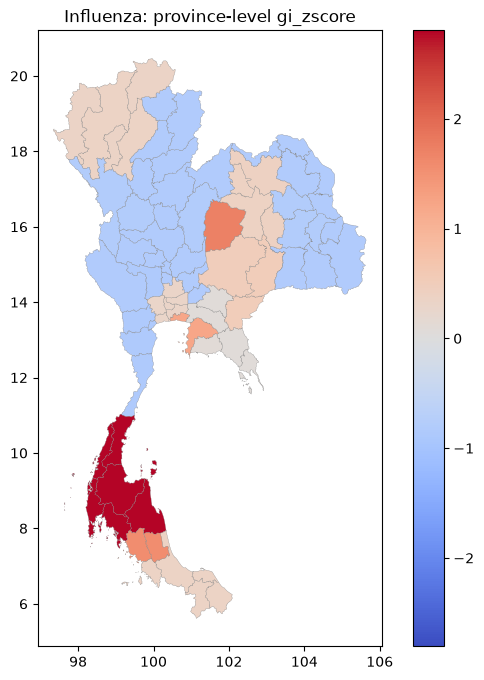

In [13]:
influenza_df = person_df[person_df["disease"] == "Influenza"]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    influenza_province = province_hotspots(influenza_df, lon_col="long", lat_col="lat", k=5, permutations=499)

plot_hotspots(influenza_province).set_title("Influenza: province-level gi_zscore")

Text(0.5, 1.0, 'Dengue: district-level gi_zscore')

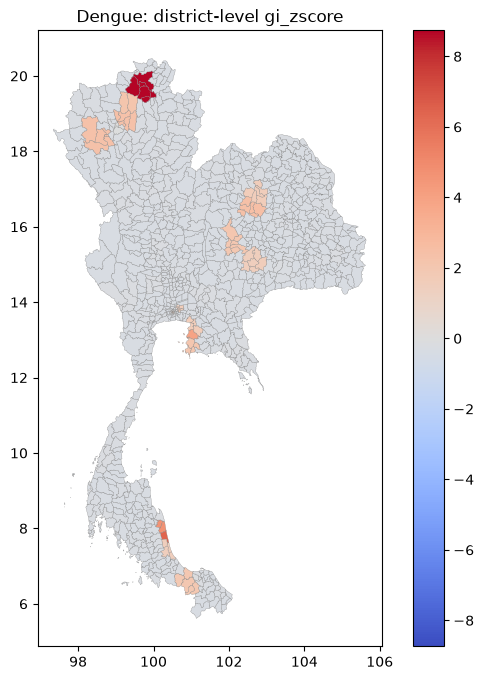

In [14]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    dengue_district = district_hotspots(dengue_df, lon_col="long", lat_col="lat", k=5, permutations=199)

plot_hotspots(dengue_district).set_title("Dengue: district-level gi_zscore")

Text(0.5, 1.0, 'Dengue: subdistrict-level gi_zscore')

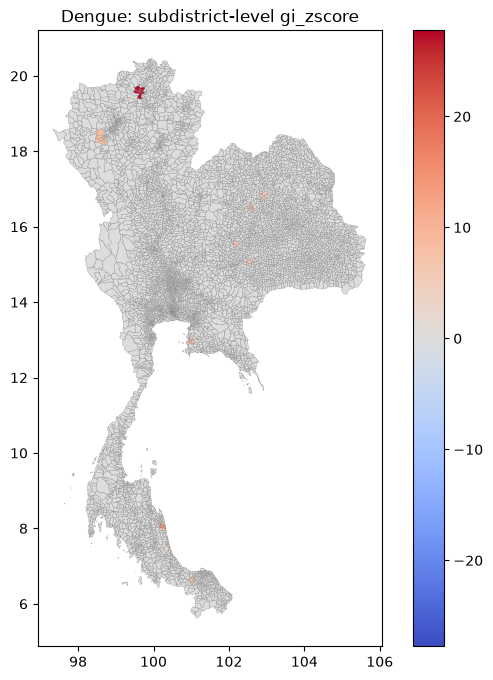

In [15]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    dengue_subdistrict = subdistrict_hotspots(dengue_df, lon_col="long", lat_col="lat", k=5, permutations=99)

plot_hotspots(dengue_subdistrict).set_title("Dengue: subdistrict-level gi_zscore")